# Dependency imports

In [10]:
import torch
from timm import create_model

from Training.library import validate
from Training.training import Config, TrainingResources, initClassifierTrainers, trainingLoop
import Training.metrics as m
import Training.plotting as plots

# CoAtNet-2 specific configuration

In [11]:
c = Config("CoAtNet-2")

#Configure execution to needs
c.purge    = False #Nagyon nincs nyúlka!!!!

c.loadBest = False

#Set hyperparams to model
#NOTE: 
#1) Készült egy mentés LR dolgozathoz képesti tizedével, 55epoch után
#2) lr 8e-7-el 10 epoch után (vajon itt érdemes csökkenteni lrt?)
c.learningRate = 8e-7
c.weightDecay  = 1e-8

#c.numClasses = 8
c.batchSize = 8
c.workers = 8


# Initialize resources

In [12]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model = create_model(
    "coatnet_2_rw_224",   # <- first parameter
    pretrained=True,    #On imageNet
    num_classes=c.numClasses
)

TR = TrainingResources(c, model, initClassifierTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

Using cuda device
Loaded state
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 8e-07
    maximize: False
    weight_decay: 1e-08
)


# Execute training

In [13]:
# Override training related config if neccesary
c.training = False
c.gpuSleep = 60
c.trainingEpochs = 30
#Decrease lr after 10ish epochs???

trainingLoop(c, TR, stopAt=0)

Training turned off


In [14]:
display(TR.history)

,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,cm_true_Melanoma_pred_Actinic keratoses,cm_true_Squamous cell carcinoma_pred_Actinic keratoses,cm_true_Vascular lesions_pred_Actinic keratoses,cm_true_Actinic keratoses_pred_Basal cell carcinoma,cm_true_Basal cell carcinoma_pred_Basal cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Basal cell carcinoma,cm_true_Dermatofibroma_pred_Basal cell carcinoma,cm_true_Melanocytic nevi_pred_Basal cell carcinoma,cm_true_Melanoma_pred_Basal cell carcinoma,cm_true_Squamous cell carcinoma_pred_Basal cell carcinoma,cm_true_Vascular lesions_pred_Basal cell carcinoma,cm_true_Actinic keratoses_pred_Benign keratosis-like lesions,cm_true_Basal cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Benign keratosis-like lesions_pred_Benign keratosis-like lesions,cm_true_Dermatofibroma_pred_Benign keratosis-like lesions,cm_true_Melanocytic nevi_pred_Benign keratosis-like lesions,cm_true_Melanoma_pred_Benign keratosis-like lesions,cm_true_Squamous cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Vascular lesions_pred_Benign keratosis-like lesions,cm_true_Actinic keratoses_pred_Dermatofibroma,cm_true_Basal cell carcinoma_pred_Dermatofibroma,cm_true_Benign keratosis-like lesions_pred_Dermatofibroma,cm_true_Dermatofibroma_pred_Dermatofibroma,cm_true_Melanocytic nevi_pred_Dermatofibroma,cm_true_Melanoma_pred_Dermatofibroma,cm_true_Squamous cell carcinoma_pred_Dermatofibroma,cm_true_Vascular lesions_pred_Dermatofibroma,cm_true_Actinic keratoses_pred_Melanocytic nevi,cm_true_Basal cell carcinoma_pred_Melanocytic nevi,cm_true_Benign keratosis-like lesions_pred_Melanocytic nevi,cm_true_Dermatofibroma_pred_Melanocytic nevi,cm_true_Melanocytic nevi_pred_Melanocytic nevi,cm_true_Melanoma_pred_Melanocytic nevi,cm_true_Squamous cell carcinoma_pred_Melanocytic nevi,cm_true_Vascular lesions_pred_Melanocytic nevi,cm_true_Actinic keratoses_pred_Melanoma,cm_true_Basal cell carcinoma_pred_Melanoma,cm_true_Benign keratosis-like lesions_pred_Melanoma,cm_true_Dermatofibroma_pred_Melanoma,cm_true_Melanocytic nevi_pred_Melanoma,cm_true_Melanoma_pred_Melanoma,cm_true_Squamous cell carcinoma_pred_Melanoma,cm_true_Vascular lesions_pred_Melanoma,cm_true_Actinic keratoses_pred_Squamous cell carcinoma,cm_true_Basal cell carcinoma_pred_Squamous cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Squamous cell carcinoma,cm_true_Dermatofibroma_pred_Squamous cell carcinoma,cm_true_Melanocytic nevi_pred_Squamous cell carcinoma,cm_true_Melanoma_pred_Squamous cell carcinoma,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.534739,0.540519,0.959135,0.664690,33,12,14,0,5,8,4,0,26,240,29,3,46,38,25,2,13,18,141,1,124,54,3,0,1,1,1,9,7,0,1,0,2,10,22,2,972,88,2,0,3,19,35,2,103,241,4,0,8,24,17,6,9,16,22,0,0,8,3,0,21,7,1,23
1,2,1.061952,0.665235,0.839145,0.699091,63,57,39,1,12,27,19,0,9,224,15,1,29,20,16,1,7,10,146,1,80,36,5,0,1,4,5,17,12,1,3,0,1,9,24,1,1002,79,2,0,3,9,23,0,135,278,3,0,2,10,7,2,3,7,14,0,0,9,3,0,14,4,0,24
2,3,0.910771,0.703484,0.840950,0.675366,64,64,31,1,10,22,27,0,5,196,8,0,19,7,7,0,12,23,179,1,119,54,7,0,1,8,5,20,22,5,2,0,0,7,14,1,907,56,0,0,3,12,19,0,198,302,3,1,1,16,4,0,1,3,16,0,0,6,2,0,11,3,0,24
3,4,0.791362,0.739019,0.721987,0.737446,51,14,12,0,6,15,3,0,8,243,12,0,22,11,11,0,14,11,179,1,66,38,8,0,

# Plots of learning process

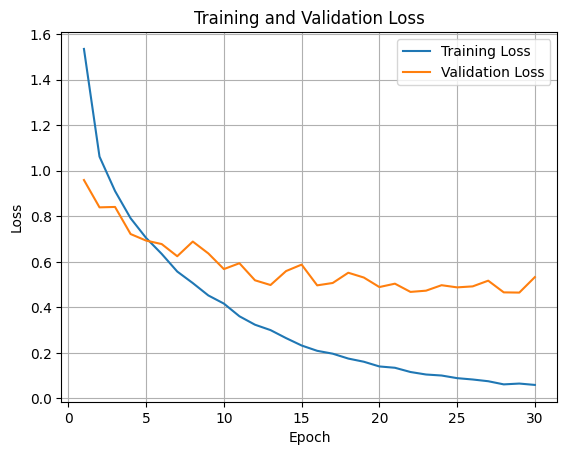

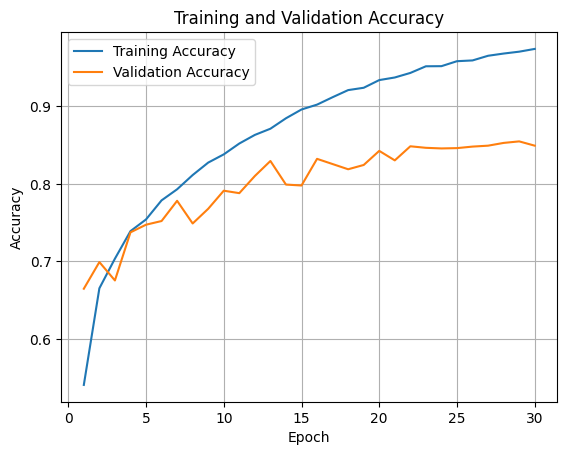

In [15]:
plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [16]:
#Reload weights with best validation
#NOTE: ATM the last trained mistakes less melanoma
c.loadBest = True

TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 0.46289275425122356 	 | Test acc: 0.8578740157480315


### Plots of test results

,accuracy,precision,recall,f1
Actinic keratoses,98.35,78.05,72.73,75.29
Basal cell carcinoma,97.17,85.95,93.69,89.66
Benign keratosis-like lesions,95.24,76.30,78.33,77.30
Dermatofibroma,99.69,90.48,76.00,82.61
Melanocytic nevi,90.79,91.56,90.14,90.85
Melanoma,91.65,76.96,75.94,76.44
Squamous cell carcinoma,99.02,84.21,75.00,79.34
Vascular lesions,99.69,78.12,96.15,86.21


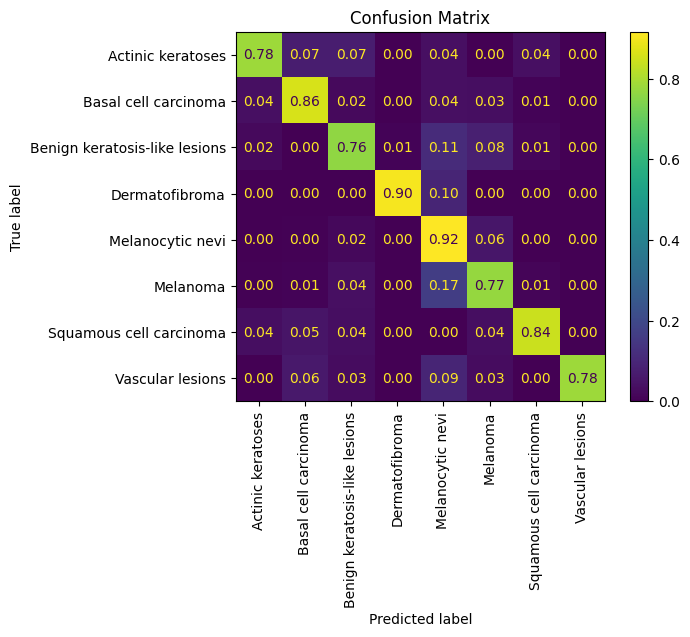

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,64,6,6,0,3,0,3,0
Basal cell carcinoma,14,312,8,0,14,12,3,0
Benign keratosis-like lesions,6,0,206,2,30,22,4,0
Dermatofibroma,0,0,0,19,2,0,0,0
Melanocytic nevi,0,6,24,4,1161,72,1,0
Melanoma,2,4,16,0,75,344,5,1
Squamous cell carcinoma,2,3,2,0,0,2,48,0
Vascular lesions,0,2,1,0,3,1,0,25


In [17]:
metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)
plots.plotConfusionMatrix(CM, TR.plotsFolder)
display(CM)

Best Melanoma validation @ epoch 30.0


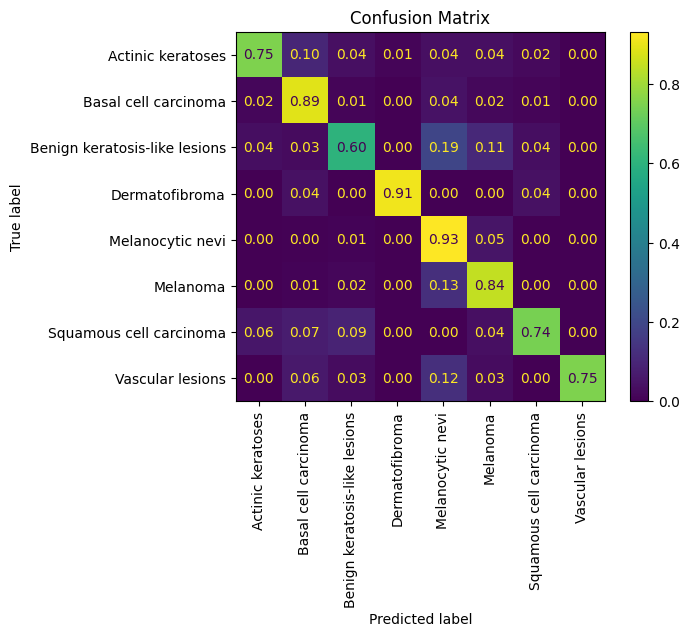

accuracy     92.84
precision    84.48
recall       73.45
f1           78.58
Name: Melanoma, dtype: float64

In [18]:
score = plots.bestMelanoma(TR)
display(score)

### Inspection using captum